In [ ]:
# !pip install pandas numpy scikit-learn torch torchvision


In [ ]:
# Installs (only run if your environment is missing these)
# !pip install pandas numpy scikit-learn torch torchvision

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


In [ ]:
# Load the FACET annotations from the csv in the repo
df = pd.read_csv("annotations.csv")

# Collect the skin tone columns (1–10)
skin_cols = [f"skin_tone_{i}" for i in range(1, 11)]

# Define "light" and "dark" using tones 1–5 (light) and 6–10 (dark)
light_cols = [f"skin_tone_{i}" for i in range(1, 6)]
dark_cols  = [f"skin_tone_{i}" for i in range(6, 11)]

df["race_light"] = df[light_cols].max(axis=1)
df["race_dark"]  = df[dark_cols].max(axis=1)

# Binary protected attribute for adversarial debiasing
# 0 = light / mid tones, 1 = darker tones
df["race_bin"] = df["race_dark"].astype(int)

df[skin_cols + ["race_bin"]].head()


,skin_tone_1,skin_tone_2,skin_tone_3,skin_tone_4,skin_tone_5,skin_tone_6,skin_tone_7,skin_tone_8,skin_tone_9,skin_tone_10,race_bin
0,2,3,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0
3,0,0,2,0,0,0,0,0,0,0,0
4,0,0,0,0,1,1,2,1,0,0,2


### Creating a Race Group from Skin Tone Columns
This part loads the dataset and groups the ten skin tone columns into lighter tones (1–5) and darker tones (6–10). The new `race_bin` column is just a quick way to mark whether someone falls into the darker tone group, which we’ll use later as the protected attribute for debiasing.

### What the Output Shows
The table shows the first few rows of skin tone values along with the `race_bin` label. A `0` means the person only has lighter tones, and a nonzero value means darker tones are present. This lets us check that the grouping worked before moving on.


In [ ]:
# Target label: is this person masculine presenting (1) or not (0)
y = df["gender_presentation_masc"].values.astype(np.int64)

# Protected attribute: race (light vs dark)
# Make absolutely sure it's only 0 or 1
z_raw = df["race_bin"].fillna(0).astype(int).values
z = (z_raw > 0).astype(np.int64)  # any nonzero becomes 1


## Drop columns that would leak the label or protected attribute directly
drop_cols = (
    [
        "gender_presentation_masc",
        "gender_presentation_fem",
        "gender_presentation_non_binary",
        "gender_presentation_na",
        "race_light",
        "race_dark",
        "race_bin",
    ]
    + skin_cols
)

# Start with all columns except the dropped ones
candidate_cols = [c for c in df.columns if c not in drop_cols]

# Keep ONLY numeric feature columns
numeric_cols = df[candidate_cols].select_dtypes(include=[np.number]).columns.tolist()

feature_cols = numeric_cols

# Use numeric one-hot columns as features
X = df[feature_cols].values.astype(np.float32)

print("Number of numeric features:", len(feature_cols))
feature_cols[:15]


Number of numeric features: 35


['Unnamed: 0',
 'person_id',
 'skin_tone_na',
 'age_presentation_young',
 'age_presentation_older',
 'age_presentation_middle',
 'age_presentation_na',
 'hair_color_brown',
 'hair_color_blonde',
 'hair_color_grey',
 'hair_color_na',
 'hair_color_black',
 'hair_color_colored',
 'hair_color_red',
 'hairtype_coily']

### Setting up labels and feature columns
Here I set up the main pieces the model will use. The target `y` is a simple label for whether someone is masc-presenting or not. The protected attribute `z` comes from `race_bin`, and I force it to be strictly 0 or 1 so the adversary can treat it as a clean light vs dark group.

I also drop any columns that would leak the label or the protected attribute directly, like the gender presentation columns and the skin tone columns. From the remaining columns, I only keep numeric ones so the model is working with one-hot style features from the annotations file. The printout shows that I end up with 35 numeric features, including things like age presentation, hair color, and hair type. The `Unnamed: 0` and `person_id` columns are just index and ID fields from `annotations.csv`, but they are numeric so they get pulled in as features too.


In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test, z_train, z_test = train_test_split(
    X, y, z, test_size=0.3, random_state=42, stratify=y
)

# Standardize features so the network trains more smoothly
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
z_train_t = torch.tensor(z_train)

X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)
z_test_t = torch.tensor(z_test)

# Wrap everything in DataLoader objects
train_ds = TensorDataset(X_train_t, y_train_t, z_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t, z_test_t)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)


### Train–test split and data setup
This part splits the annotation features into training and testing sets so the model can learn on one portion of the data and be evaluated on another. I standardize the numeric features to help the network train more smoothly. After that, I convert everything into tensors and create DataLoader objects, which just batch and shuffle the data during training. There’s no printed output here because this


In [ ]:
input_dim = X_train.shape[1]

class MainNet(nn.Module):
    """
    Simple feedforward network for the main prediction task.
    Takes tabular features and predicts masc vs not masc.
    """
    def __init__(self, in_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: 0, 1

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)
        return out, h  # return logits and hidden representation


class AdvNet(nn.Module):
    """
    Adversary that tries to predict race (light vs dark)
    from the hidden representation of MainNet.
    """
    def __init__(self, in_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 64)
        self.fc2 = nn.Linear(64, 2)  # 2 race groups

    def forward(self, h):
        h2 = F.relu(self.fc1(h))
        out = self.fc2(h2)
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

main_model = MainNet(input_dim).to(device)
adv_model  = AdvNet(128).to(device)  # 128 matches MainNet's hidden size

opt_main = torch.optim.Adam(main_model.parameters(), lr=1e-3)
opt_adv  = torch.optim.Adam(adv_model.parameters(), lr=1e-3)

criterion = nn.CrossEntropyLoss()
lambda_adv = 0.5  # how strongly we push against race prediction


### Main model and adversary setup
This section builds the two neural networks we need for adversarial debiasing. The main model predicts whether someone is masc-presenting using the numeric features from the annotations. The adversary takes the hidden layer from the main model and tries to predict the race group (light vs dark). During training, the adversary pushes the model to hide race information in its internal representation. This cell also sets up the optimizers, loss function, and the strength of the adversarial signal.


In [ ]:
def group_accuracy(preds, labels, race, group_value):
    """
    Compute accuracy for one race group.
    group_value: 0 for light, 1 for dark.
    """
    mask = (race == group_value)
    if mask.sum() == 0:
        return float("nan")
    return (preds[mask] == labels[mask]).float().mean().item()


### Group accuracy helper function
This small function calculates accuracy for one race group at a time. It lets me compare how well the model does on lighter-skinned individuals versus darker-skinned individuals. The function doesn’t produce output on its own because it's only a definition.

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    main_model.train()
    adv_model.train()

    for Xb, yb, zb in train_loader:
        Xb = Xb.to(device)
        yb = yb.to(device)
        zb = zb.to(device)

        # ----- Step 1: train adversary on current features -----
        # we don't update the main model in this step
        with torch.no_grad():
            _, h_feat = main_model(Xb)
        logits_race = adv_model(h_feat.detach())
        loss_adv = criterion(logits_race, zb)

        opt_adv.zero_grad()
        loss_adv.backward()
        opt_adv.step()

        # ----- Step 2: train main model to predict y and hide race -----
        logits_y, h_feat = main_model(Xb)
        loss_task = criterion(logits_y, yb)

        # adversary tries to predict race from h_feat
        logits_adv_for_main = adv_model(h_feat)
        loss_adv_for_main = criterion(logits_adv_for_main, zb)

        # main model wants good task loss and to make adversary worse
        total_loss = loss_task - lambda_adv * loss_adv_for_main

        opt_main.zero_grad()
        total_loss.backward()
        opt_main.step()

    # ----- quick evaluation at the end of each epoch -----
    main_model.eval()
    all_preds = []
    all_labels = []
    all_race = []

    with torch.no_grad():
        for Xb, yb, zb in test_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            zb = zb.to(device)

            logits_y, _ = main_model(Xb)
            preds = torch.argmax(logits_y, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())
            all_race.append(zb.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    all_race = torch.cat(all_race)

    acc_overall = (all_preds == all_labels).float().mean().item()
    acc_light = group_accuracy(all_preds, all_labels, all_race, 0)
    acc_dark  = group_accuracy(all_preds, all_labels, all_race, 1)

    print(
        f"Epoch {epoch+1:02d} | overall: {acc_overall:.3f} | "
        f"light: {acc_light:.3f} | dark: {acc_dark:.3f}"
    )


Epoch 01 | overall: 0.782 | light: 0.774 | dark: 0.796
Epoch 02 | overall: 0.780 | light: 0.771 | dark: 0.795
Epoch 03 | overall: 0.783 | light: 0.774 | dark: 0.799
Epoch 04 | overall: 0.786 | light: 0.776 | dark: 0.801
Epoch 05 | overall: 0.786 | light: 0.778 | dark: 0.800
Epoch 06 | overall: 0.786 | light: 0.776 | dark: 0.801
Epoch 07 | overall: 0.788 | light: 0.779 | dark: 0.801
Epoch 08 | overall: 0.788 | light: 0.781 | dark: 0.800
Epoch 09 | overall: 0.791 | light: 0.785 | dark: 0.801
Epoch 10 | overall: 0.790 | light: 0.781 | dark: 0.805


### Training loop and per-epoch accuracy
This loop trains both the main model and the adversary over 10 epochs. For each batch, the adversary first learns to predict the race group from the hidden features, and then the main model updates to do well on the masc vs not masc task while pushing back against race prediction. At the end of each epoch, I check accuracy overall and separately for the light and dark skin tone groups.

The printed output shows that overall accuracy stays around 0.78–0.79, which is fairly stable. The light group sits around 0.77–0.78 and the dark group around 0.80. The gap between the two groups is small, and in this setup the dark group is actually doing slightly better, which is interesting given how underrepresented darker tones are in the dataset.


In [ ]:
main_model.eval()
all_preds = []
all_labels = []
all_race = []

with torch.no_grad():
    for Xb, yb, zb in test_loader:
        Xb = Xb.to(device)
        yb = yb.to(device)
        zb = zb.to(device)

        logits_y, _ = main_model(Xb)
        preds = torch.argmax(logits_y, dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(yb.cpu())
        all_race.append(zb.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_race = torch.cat(all_race)

acc_overall = (all_preds == all_labels).float().mean().item()
acc_light = group_accuracy(all_preds, all_labels, all_race, 0)
acc_dark  = group_accuracy(all_preds, all_labels, all_race, 1)

print("Final overall accuracy:", round(acc_overall, 3))
print("Accuracy (light group):", round(acc_light, 3))
print("Accuracy (dark group):", round(acc_dark, 3))


Final overall accuracy: 0.79
Accuracy (light group): 0.781
Accuracy (dark group): 0.805


### Final evaluation
This last step checks how the trained model performs on the test set. I compute the overall accuracy and then break it down for the light and dark skin tone groups. The final numbers show an overall accuracy of about 0.79, with the light group at 0.781 and the dark group at 0.805. The two groups are fairly close, which suggests the adversarial training kept the performance gap from getting too large. These results will be useful to compare against a baseline model without debiasing to see how much the adversarial setup changes fairness.


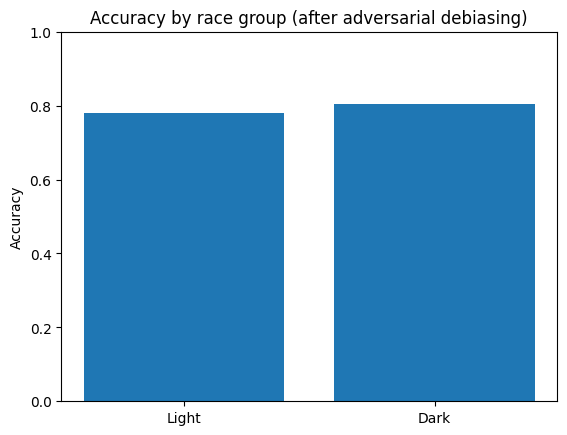

In [ ]:
import matplotlib.pyplot as plt

groups = ["Light", "Dark"]
accs = [acc_light, acc_dark]

plt.figure()
plt.bar(groups, accs)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy by race group (after adversarial debiasing)")
plt.show()


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "group": ["overall", "light", "dark"],
    "accuracy": [acc_overall, acc_light, acc_dark]
})
results_df


,group,accuracy
0,overall,0.790327
1,light,0.780687
2,dark,0.805331
